In [ ]:
Objetivo:

-Explorar la distribucion geografica de los terremotos
-Estudiar la relaccion entre magnitud y profundidad
-Visualizar la evolucion temporal de la actividad sismica

In [62]:
#Bibliotecas necesarias para llevar a cabo la tarea
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

In [19]:
#Aqui establecemos la ruta para leer el archivo CSV que se nos ha proporcionado para el trabajo
#En la variable ruta especificariamos la necesaria, ejemplo: "C:/Users/..."
ruta = "C:/Users/abrah/Desktop/Programacion/MACHINE LEARNING/Día 17/earthquake+data.csv" 
df_raw = pd.read_csv(ruta)

In [63]:
#Aqui nos aseguramos de ver los tipos de datos del DataFrame, tanto el tipo, como la cantidad de datos, y si hay algun dato null:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52767 entries, 0 to 52766
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date & Time  52767 non-null  object 
 1   Latitude     52767 non-null  float64
 2   Longitude    52767 non-null  float64
 3   Depth        52767 non-null  int64  
 4   Magnitude    52767 non-null  float64
 5   Lands        52767 non-null  object 
 6   Country      52767 non-null  object 
dtypes: float64(3), int64(1), object(3)
memory usage: 2.8+ MB


In [64]:
#Aqui visualizamos los datos, tambien redondeamos sus decimales a 2 para que sea mas facil y limpio interpretar los datos
df_raw.head(10).round(2)

,Date & Time,Latitude,Longitude,Depth,Magnitude,Lands,Country
0,11/21/2023 16:36,38243.0,38808.00,7,1.0,EASTERN,TURKEY
1,11/21/2023 15:59,39134.0,29026.00,10,1.0,WESTERN,TURKEY
2,11/21/2023 13:00,39636.0,30104.00,7,1.0,WESTERN,TURKEY
3,11/20/2023 18:43,47368.0,6918.00,5,1.0,SWITZERLAND,SWITZERLAND
4,11/19/2023 10:48,37175.0,36892.00,7,1.0,CENTRAL,TURKEY
5,11/18/2023 12:38,37207.0,36882.00,8,1.0,CENTRAL,TURKEY
6,11/18/2023 0:50,38156.0,38542.00,7,1.0,EASTERN,TURKEY
7,11/17/2023 9:05,45582.0,13.93,8,1.0,SLOVENIA,SLOVENIA
8,11/17/2023 8:47,46345.0,13658.00,4,1.0,SLOVENIA,SLOVENIA
9,11/16/2023 3:39,46184.0,7988.00,2,1.0,SWITZERLAND,SWITZERLAND


In [ ]:
EDA  ---  Analisis Exploratorio de Datos

In [41]:
#Realizamos "EDA", para comprobar la magnitud maxima, como la minima, tambien la media y mediana de los valores en la columna "Magnitud"
print("Distribución de Magnitudes:")
print(f"  Mínima:  {df_raw['Magnitude'].min():.1f}")
print(f"  Máxima:  {df_raw['Magnitude'].max():.1f}")
print(f"  Media:   {df_raw['Magnitude'].mean():.2f}")
print(f"  Mediana: {df_raw['Magnitude'].median():.1f}")

print("\n5 países con más terremotos:")
print(df_raw["Country"].value_counts().head())

Distribución de Magnitudes:
  Mínima:  1.0
  Máxima:  7.7
  Media:   3.00
  Mediana: 2.9

5 países con más terremotos:
Country
TURKEY       5793
REGION       5470
MEXICO       5450
INDONESIA    3865
CHILE        3022
Name: count, dtype: int64


In [ ]:
Preparamos el dataset
-En este caso utilizare 2.000 registros como ejemplo, para optimizar el rendimiento de los graficos mostrados a continuacion

In [45]:
#Vamos a optimizar nuestro Df, escogemos 2000 filas
df = df_raw.sample(n=2000, random_state=42).copy()

# Aqui establezco la columna "Date & Time" como tipo de dato "datetime64" esto nos evitara errores en el futuro y hara mas limpio el analisis de datos
df["Date & Time"] = pd.to_datetime(df["Date & Time"])
df = df.sort_values("Date & Time").reset_index(drop=True)

# Aqui establezco una columna que contenga unicamente el año, hara mas facil la creacion de graficos en el futuro
df["Year"] = df["Date & Time"].dt.year

# Aqui creo una funcion que sirve para establecer unos rangos de fuerza de magnitud, simplemente hara que los datos posteriores sean mas legibles
def clasificar_magnitud(m):
    if m < 4.0:
        return "Leve (< 4.0)"
    elif m < 6.0:
        return "Moderado (4.0–6.0)"
    elif m < 7.0:
        return "Fuerte (6.0–7.0)"
    else:
        return "Mayor (≥ 7.0)"
        
#Aplico la funcion "clasificar_magnitud"
df["Categoria"] = df["Magnitude"].apply(clasificar_magnitud)
df.head(10)

,Date & Time,Latitude,Longitude,Depth,Magnitude,Lands,Country,Year,Categoria
0,2023-05-14 13:55:00,33.45,139.45,10,5.0,"IZU, ISLANDS,, JAPAN",REGION,2023,Moderado (4.0–6.0)
1,2023-05-14 14:24:00,37.79,36.55,6,2.7,CENTRAL,TURKEY,2023,Leve (< 4.0)
2,2023-05-14 14:35:00,27.58,140.00,417,4.2,"BONIN, ISLANDS,, JAPAN",REGION,2023,Moderado (4.0–6.0)
3,2023-05-14 17:48:00,-18.65,-70.53,34,2.8,"OFFSHORE, TARAPACA,",CHILE,2023,Leve (< 4.0)
4,2023-05-14 17:57:00,75.50,7.67,10,4.6,GREENLAND,SEA,2023,Moderado (4.0–6.0)
5,2023-05-14 20:18:00,16.59,-98.19,2,3.0,"OAXACA,",MEXICO,2023,Leve (< 4.0)
6,2023-05-14 21:17:00,-24.25,-67.03,217,4.0,"SALTA,",ARGENTINA,2023,Moderado (4.0–6.0)
7,2023-05-14 23:20:00,53.64,-163.86,35,2.5,"UNIMAK, ISLAND, REGION,",ALASKA,2023,Leve (< 4.0)
8,2023-05-14 23:34:00,17.96,-66.95,10,2.4,PUERTO,RICO,2023,Leve (< 4.0)
9,2023-05-15 03:20:00,40.23,-121.17,6,2.6,NORTHERN,CALIFORNIA,2023,Leve (< 4.0)


In [ ]:
Visualizaciones

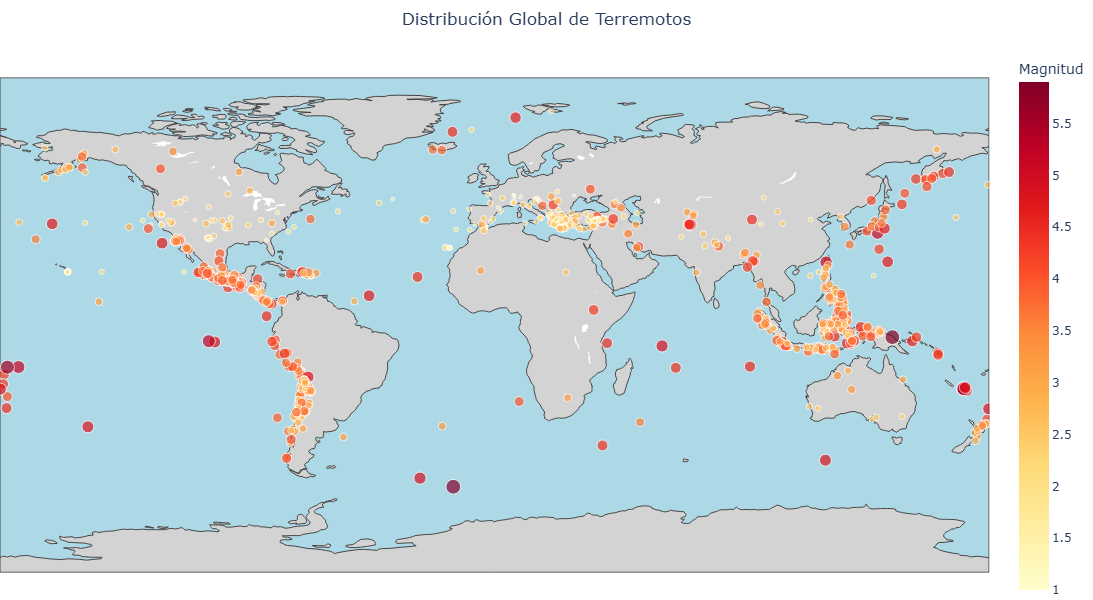

In [55]:
#-Mapa geografico, cada punto representa un terremoto, el tamaño y color reflejan su magnitud

#Aqui creo una funcion encargada de generar el mapa, en este caso sera un mapa geografico
def create_map(data):
    fig = go.Figure(go.Scattergeo(
        lon=data["Longitude"],
        lat=data["Latitude"],
        
        #Aqui establezco la informacion que da cada punto en el mapa, cuando pasas el cursor sobre el, en este caso profundidad y magnitud
        text=data["Country"] + "<br>Magnitud: " + data["Magnitude"].astype(str) +
             "<br>Profundidad: " + data["Depth"].astype(str) + " km",
        hoverinfo="text",
        mode="markers",
        marker=dict(
            size=data["Magnitude"] * 2.5,
            color=data["Magnitude"],
            colorscale="YlOrRd",
            showscale=True,
            colorbar=dict(title="Magnitud"),
            opacity=0.7
        )
    ))
    
    #Aqui personalizo el mapa, tanto con el color de oceano, como el tamaño, titulo, etc
    fig.update_layout(
        title="Distribución Global de Terremotos",
        title_x=0.5,
        height=600,
        margin=dict(l=0, r=0, t=50, b=0),
        geo=dict(showland=True, landcolor="lightgray", showocean=True, oceancolor="lightblue")
    )
    return fig

figcor = create_map(df)
figcor.show()

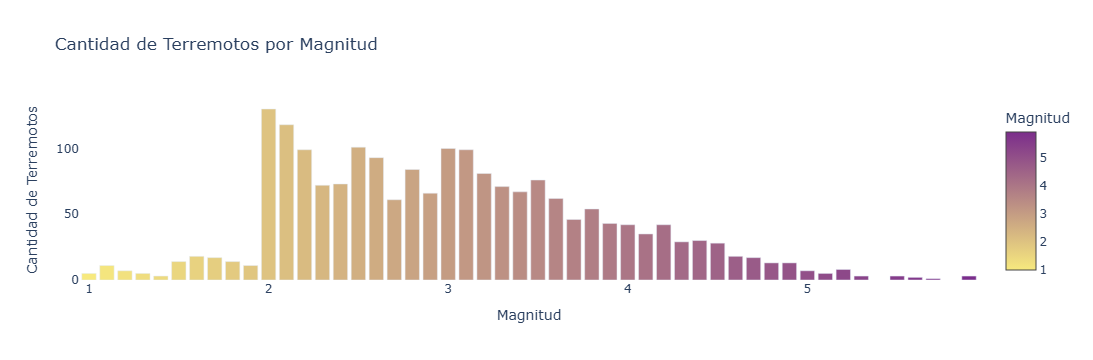

In [54]:
#Histograma, frecuencia de terremotos segun su magnitud

#Aqui creo la funcion encargada de generar el histograma
def create_bar(data):
    conteo = data.groupby("Magnitude").size().reset_index(name="Cantidad")
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=conteo["Magnitude"],
        y=conteo["Cantidad"],
        marker=dict(
            color=conteo["Magnitude"],
            colorscale=[[0, "#f7e97e"], [1, "#7b2d8b"]],
            showscale=True,
            colorbar=dict(title="Magnitud")
        ),
        hovertemplate="Magnitud: %{x}<br>Terremotos: %{y}<extra></extra>"
    ))

    #personalizacion de histograma, establezco el titulo del grafico como el titulo de los ejes y el color de fondo
    fig.update_layout(
        title="Cantidad de Terremotos por Magnitud",
        xaxis_title="Magnitud",
        yaxis_title="Cantidad de Terremotos",
        plot_bgcolor="white"
    )
    return fig

figbar = create_bar(df)
figbar.show()

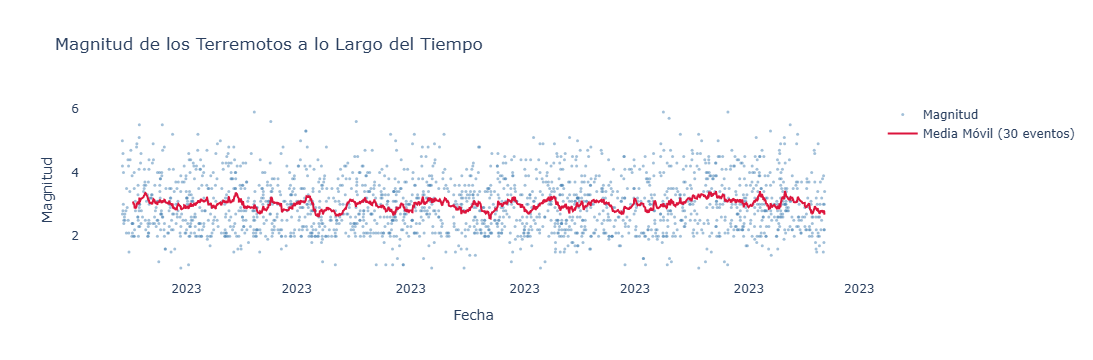

In [57]:
#Creo un grafico Scatter con todos los datos de mustra, incluyo una linea de media movil para identificar tendencias

#Aqui creo una funcion encargada de generar el Scatter y la media movil
def create_line(data):
    # Media móvil de 30 eventos
    data = data.copy()
    data["Media_Movil"] = data["Magnitude"].rolling(window=30).mean()

    fig = go.Figure()

    #Creo el grafico Scatter
    fig.add_trace(go.Scatter(
        x=data["Date & Time"],
        y=data["Magnitude"],
        mode="markers",
        name="Magnitud",
        marker=dict(size=3, color="steelblue", opacity=0.5)
    ))

    #Añado la media movil al grafico
    fig.add_trace(go.Scatter(
        x=data["Date & Time"],
        y=data["Media_Movil"],
        mode="lines",
        name="Media Móvil (30 eventos)",
        line=dict(color="crimson", width=2)
    ))

    #Personalizo titulos, nombres de ejes, color de fondo, etc
    fig.update_layout(
        title="Magnitud de los Terremotos a lo Largo del Tiempo",
        xaxis_title="Fecha",
        yaxis_title="Magnitud",
        xaxis=dict(tickformat="%Y"),
        plot_bgcolor="white",
        hovermode="x unified"
    )
    return fig

figlin = create_line(df)
figlin.show()

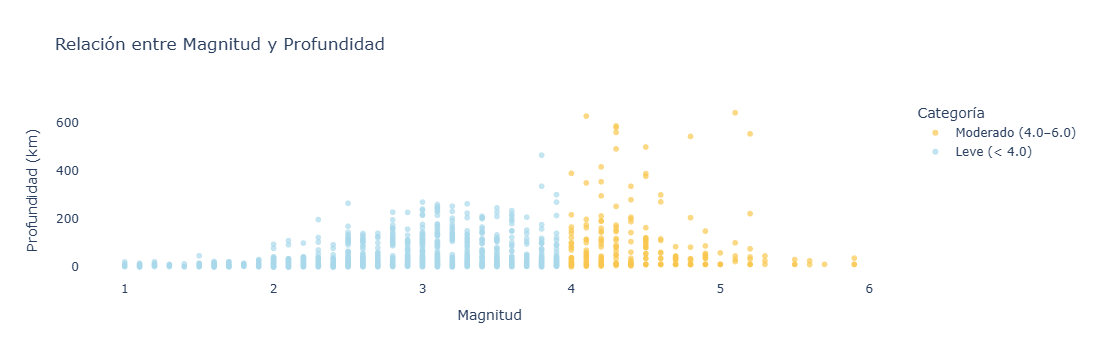

In [59]:
#Creo un grafico Scatter para comprobar la relacion entre Magnitud y Profundidad

#Creo la funcion encargada de generar el grafico Scatter(dispersion)
def create_scatter(data):

    #Establezco un mapa de colores segun su magnitud, nos ayudara a visualizar mejor los datos
    color_map = {
        "Leve (< 4.0)": "#a8d8ea",
        "Moderado (4.0–6.0)": "#f9c74f",
        "Fuerte (6.0–7.0)": "#f4721e",
        "Mayor (≥ 7.0)": "#c1121f"
    }

    #Genero el grafico Scatter
    fig = px.scatter(
        data,
        x="Magnitude",
        y="Depth",
        color="Categoria",
        color_discrete_map=color_map,
        hover_data=["Country", "Date & Time"],
        opacity=0.7,
        title="Relación entre Magnitud y Profundidad"
    )
    
    #Personalizo el grafico
    fig.update_layout(
        xaxis_title="Magnitud",
        yaxis_title="Profundidad (km)",
        plot_bgcolor="white",
        legend_title="Categoría"
    )
    return fig

figsca = create_scatter(df)
figsca.show()

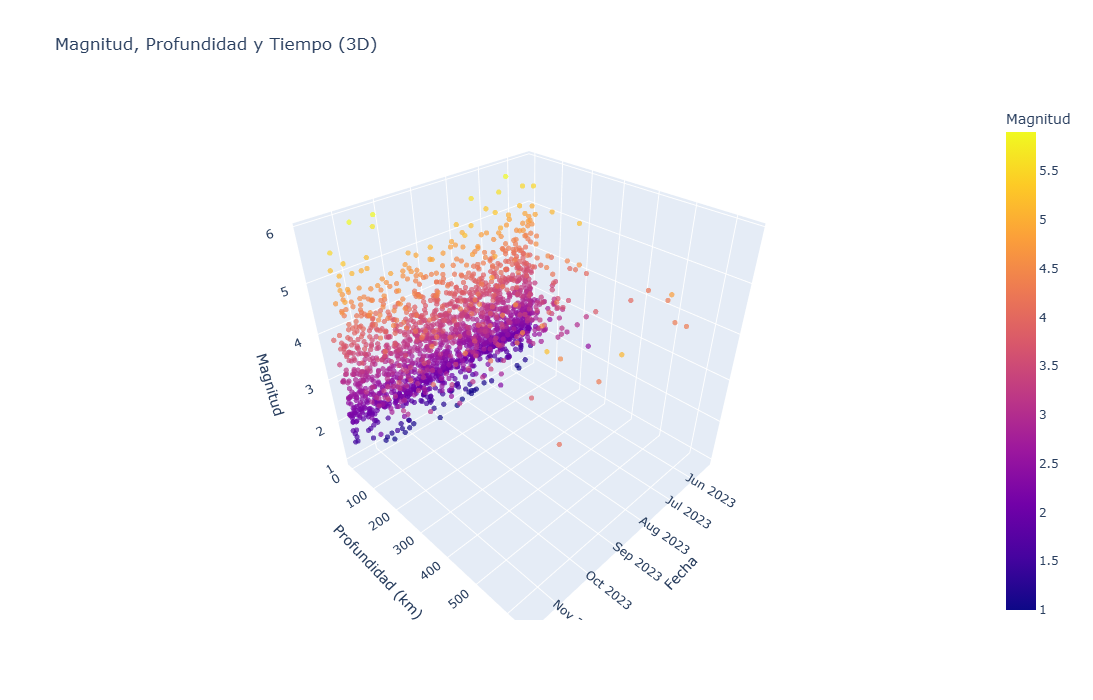

In [61]:
#Creo un Grafico 3D con los datos de Magnitud, Profundidad y tiempo

#Aqui creo la funcion encargada de generar el grafico 3d
def create_3d(data):
    fig = go.Figure()

    #Genero el grafico 3d, en este caso sera un grafico Scatter
    fig.add_trace(go.Scatter3d(
        x=data["Date & Time"],
        y=data["Depth"],
        z=data["Magnitude"],
        mode="markers",
        marker=dict(
            size=3,
            color=data["Magnitude"],
            colorscale="Plasma",
            showscale=True,
            colorbar=dict(title="Magnitud"),
            opacity=0.7
        ),
        hovertemplate="Fecha: %{x}<br>Profundidad: %{y} km<br>Magnitud: %{z}<extra></extra>"
    ))

    #Personalizo el grafico
    fig.update_layout(
        title="Magnitud, Profundidad y Tiempo (3D)",
        scene=dict(
            xaxis_title="Fecha",
            yaxis_title="Profundidad (km)",
            zaxis_title="Magnitud"
        ),
        height=700
    )
    return fig

fig3d = create_3d(df)
fig3d.show()

In [ ]:
Conclusiones a partir de los datos selecionados en el dataset:

Distribucion Geografica:
-La actividad sismica se situa principalmente en el Cinturon de Fuego del Pacifico(Japon, Indonesia, Chile y California) 
tambien en la zona del Mediterraneo

Magnitud y profundidad:
-La mayopria de terremotos registrados tienen magnitudes en el rango de 4.0 - 6.0
-No observo correlacion linel clara entre Profundidad y Magnitud, aunque los terremotos muy profundos(>300km) raramente superan la magnitud 7.0

Evolucion Temporal:
-La media movil de magnitud se mantiene relativamente estable a lo largo del tiempo, sin una tendencia clara
-Los picos de mayor magnitud aparecen de forma esporadica y no estacional